<a href="https://colab.research.google.com/github/Knchna/Credit_Default_Preprocessing/blob/Kanchana/Credit_Default_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#           Credit Default Prediction using Data Preprocessing
Dataset: Default of Credit Card Clients (UCI Repository)

# Clone the Git

In [ ]:
# Clone the GitHub repository into the Google Colab environment

!git clone https://github.com/Knchna/Credit_Default_Preprocessing.git

fatal: destination path 'Credit_Default_Preprocessing' already exists and is not an empty directory.


# Libraries

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

SEED = 45

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

from sklearn.feature_selection import mutual_info_classif

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

from sklearn.utils.class_weight import compute_class_weight

# ANN
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Read the Data

In [ ]:
# filepath to the .excel file
# Load the dataset from the cloned GitHub repository

filepath = '/content/Credit_Default_Preprocessing/default of credit card clients.xls'
df_credit = pd.read_excel(filepath, header=1)
df_credit.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


#EDA

In [ ]:
# Identifying numerical and categorical data
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
# Identifying dataset size
df_credit.shape

(30000, 25)

In [ ]:
df_credit.describe()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## Missing values

In [ ]:
# Trying to findout if there is any missing value present
df_credit.isna().sum()
# no missing values found

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


## Duplicated columns

In [ ]:
df_credit.duplicated().sum()

np.int64(0)

## Dropping unwanted columns

In [ ]:
# Dropping column ID because it has too many unique values
df_credit.drop(columns=['ID'],inplace=True)

In [ ]:
# After dropping 'ID'
df_credit.shape

(30000, 24)

## Replacing values

In [ ]:
# checking unique values and their values counts of column = education
df_credit['EDUCATION'].value_counts()


,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [ ]:
# replacing (0,5,6) as they are impossible values for education
df_credit['EDUCATION'] = df_credit['EDUCATION'].replace([0,5,6],4)

In [ ]:
# checking if the replace was successfull
df_credit['EDUCATION'].unique()

array([2, 1, 3, 4])

In [ ]:
# checking unique values and their values counts of column = MARRIAGE
df_credit['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


In [ ]:
# replacing (0) as they are impossible values for marriage
df_credit['MARRIAGE'] = df_credit['MARRIAGE'].replace([0],3)

In [ ]:
# checking if the replace was successfull
df_credit['MARRIAGE'].unique()

array([1, 2, 3])

## Seperating numerical and categorical data

In [ ]:
# Splitting into numerical and categorical columns

num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

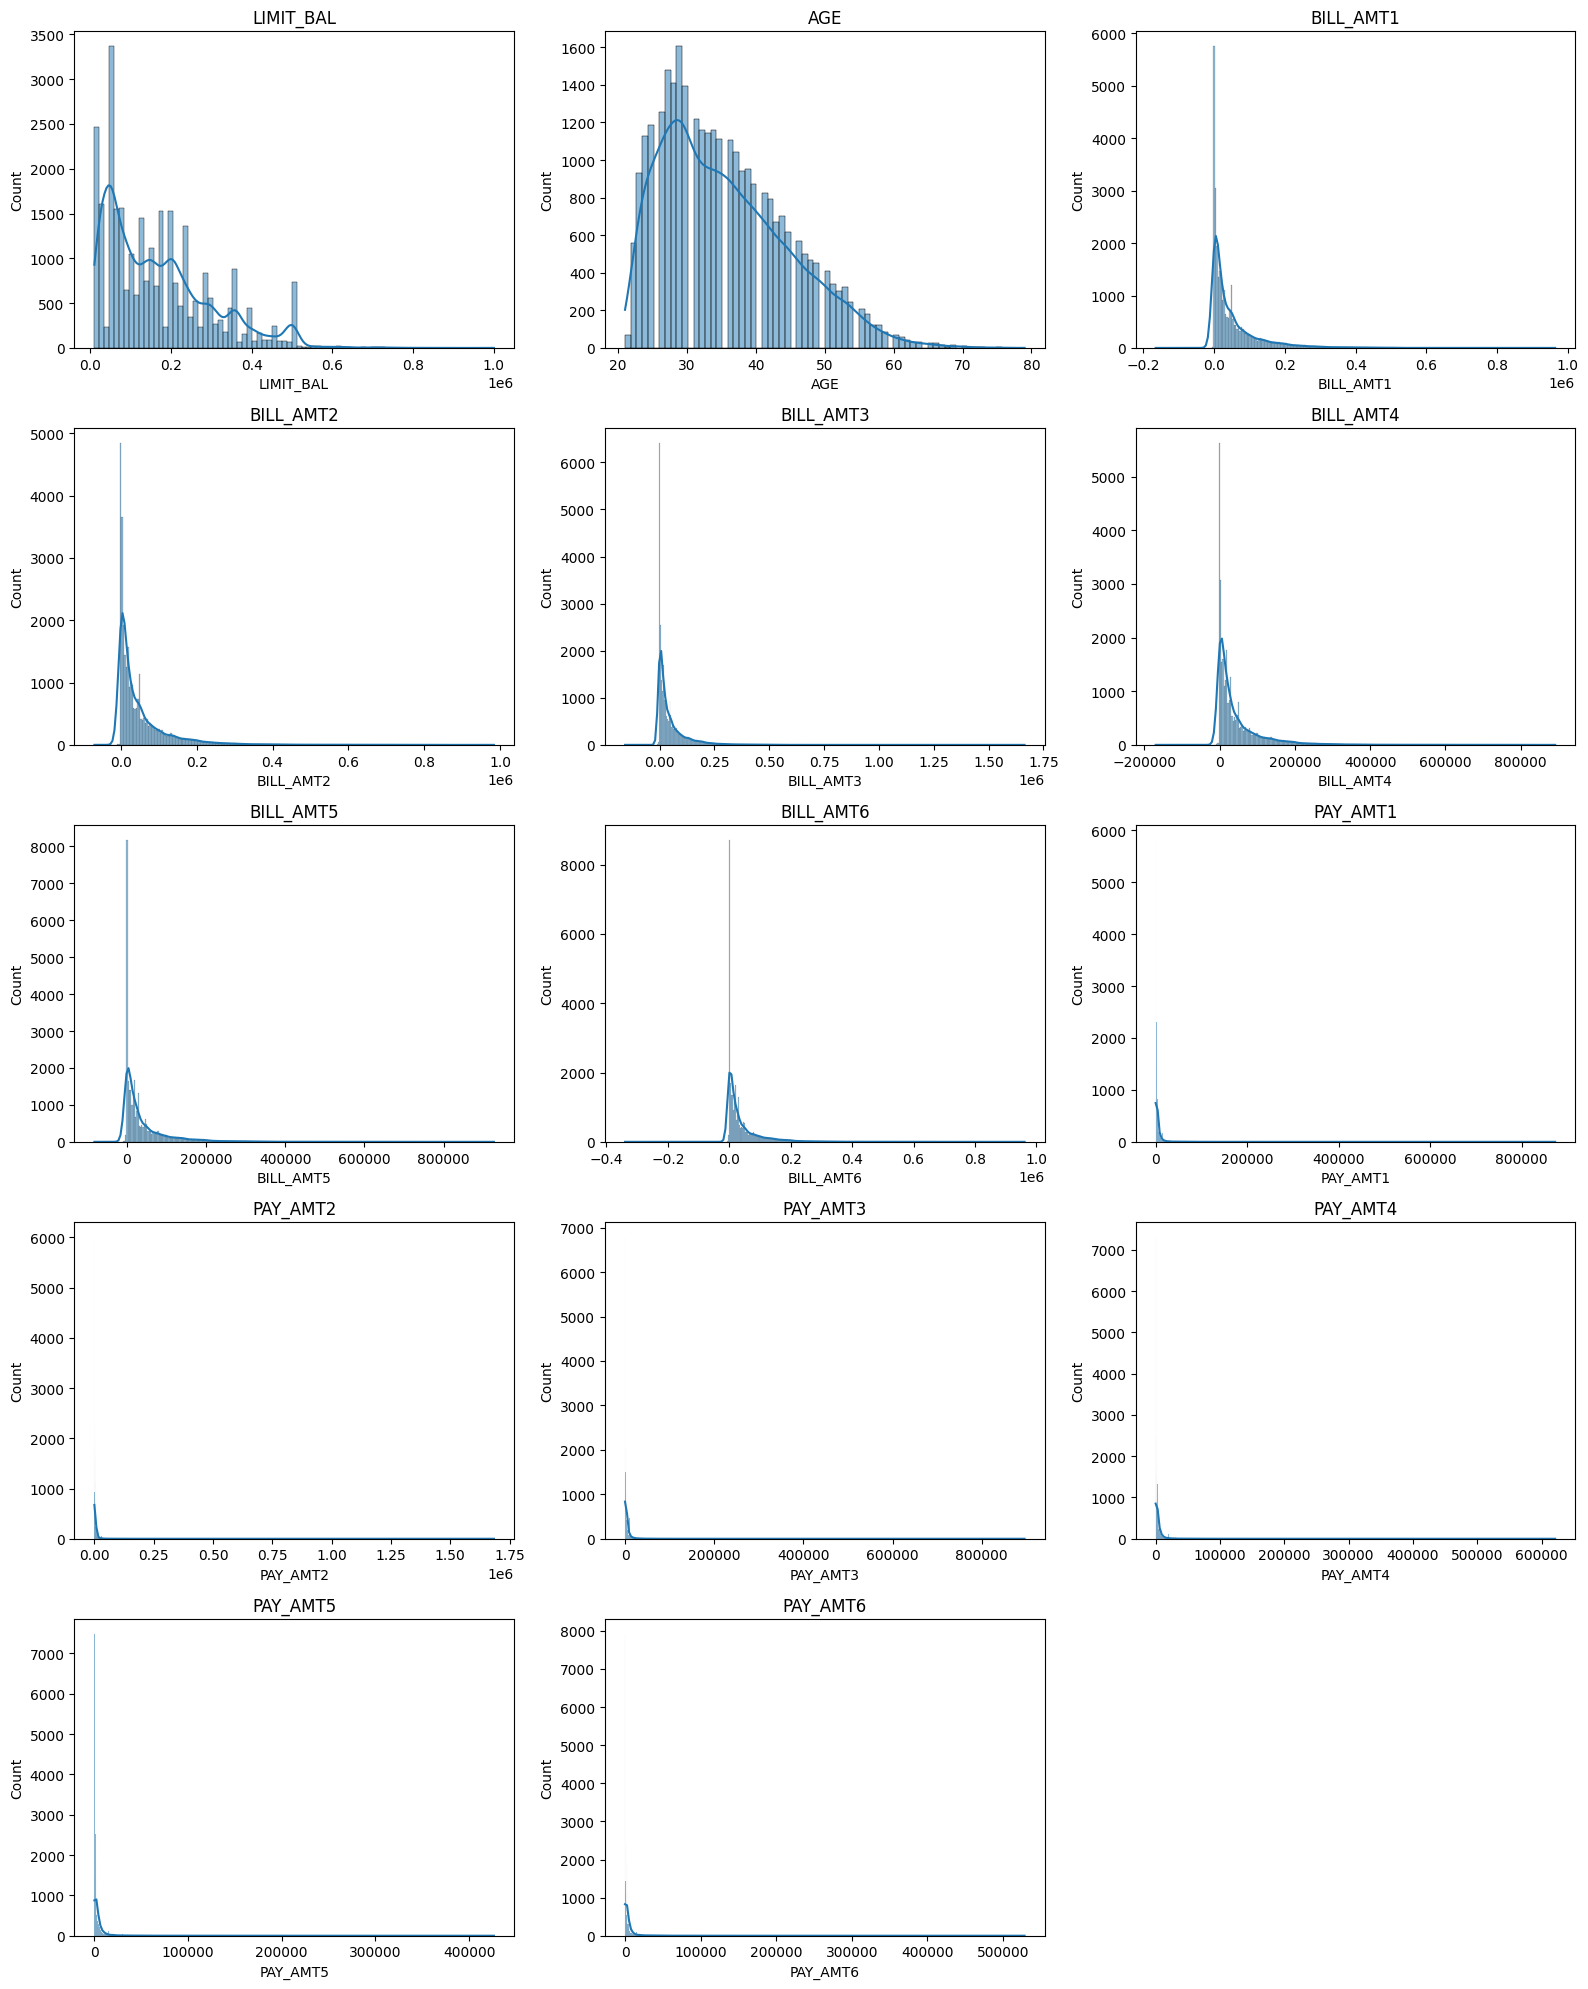

In [ ]:
# Histogram of num_cols

plt.figure(figsize = (16, 20))
i = 1
for column in num_cols:
  plt.subplot(5, 3, i)
  sns.histplot(df_credit[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

##Outlier Handling

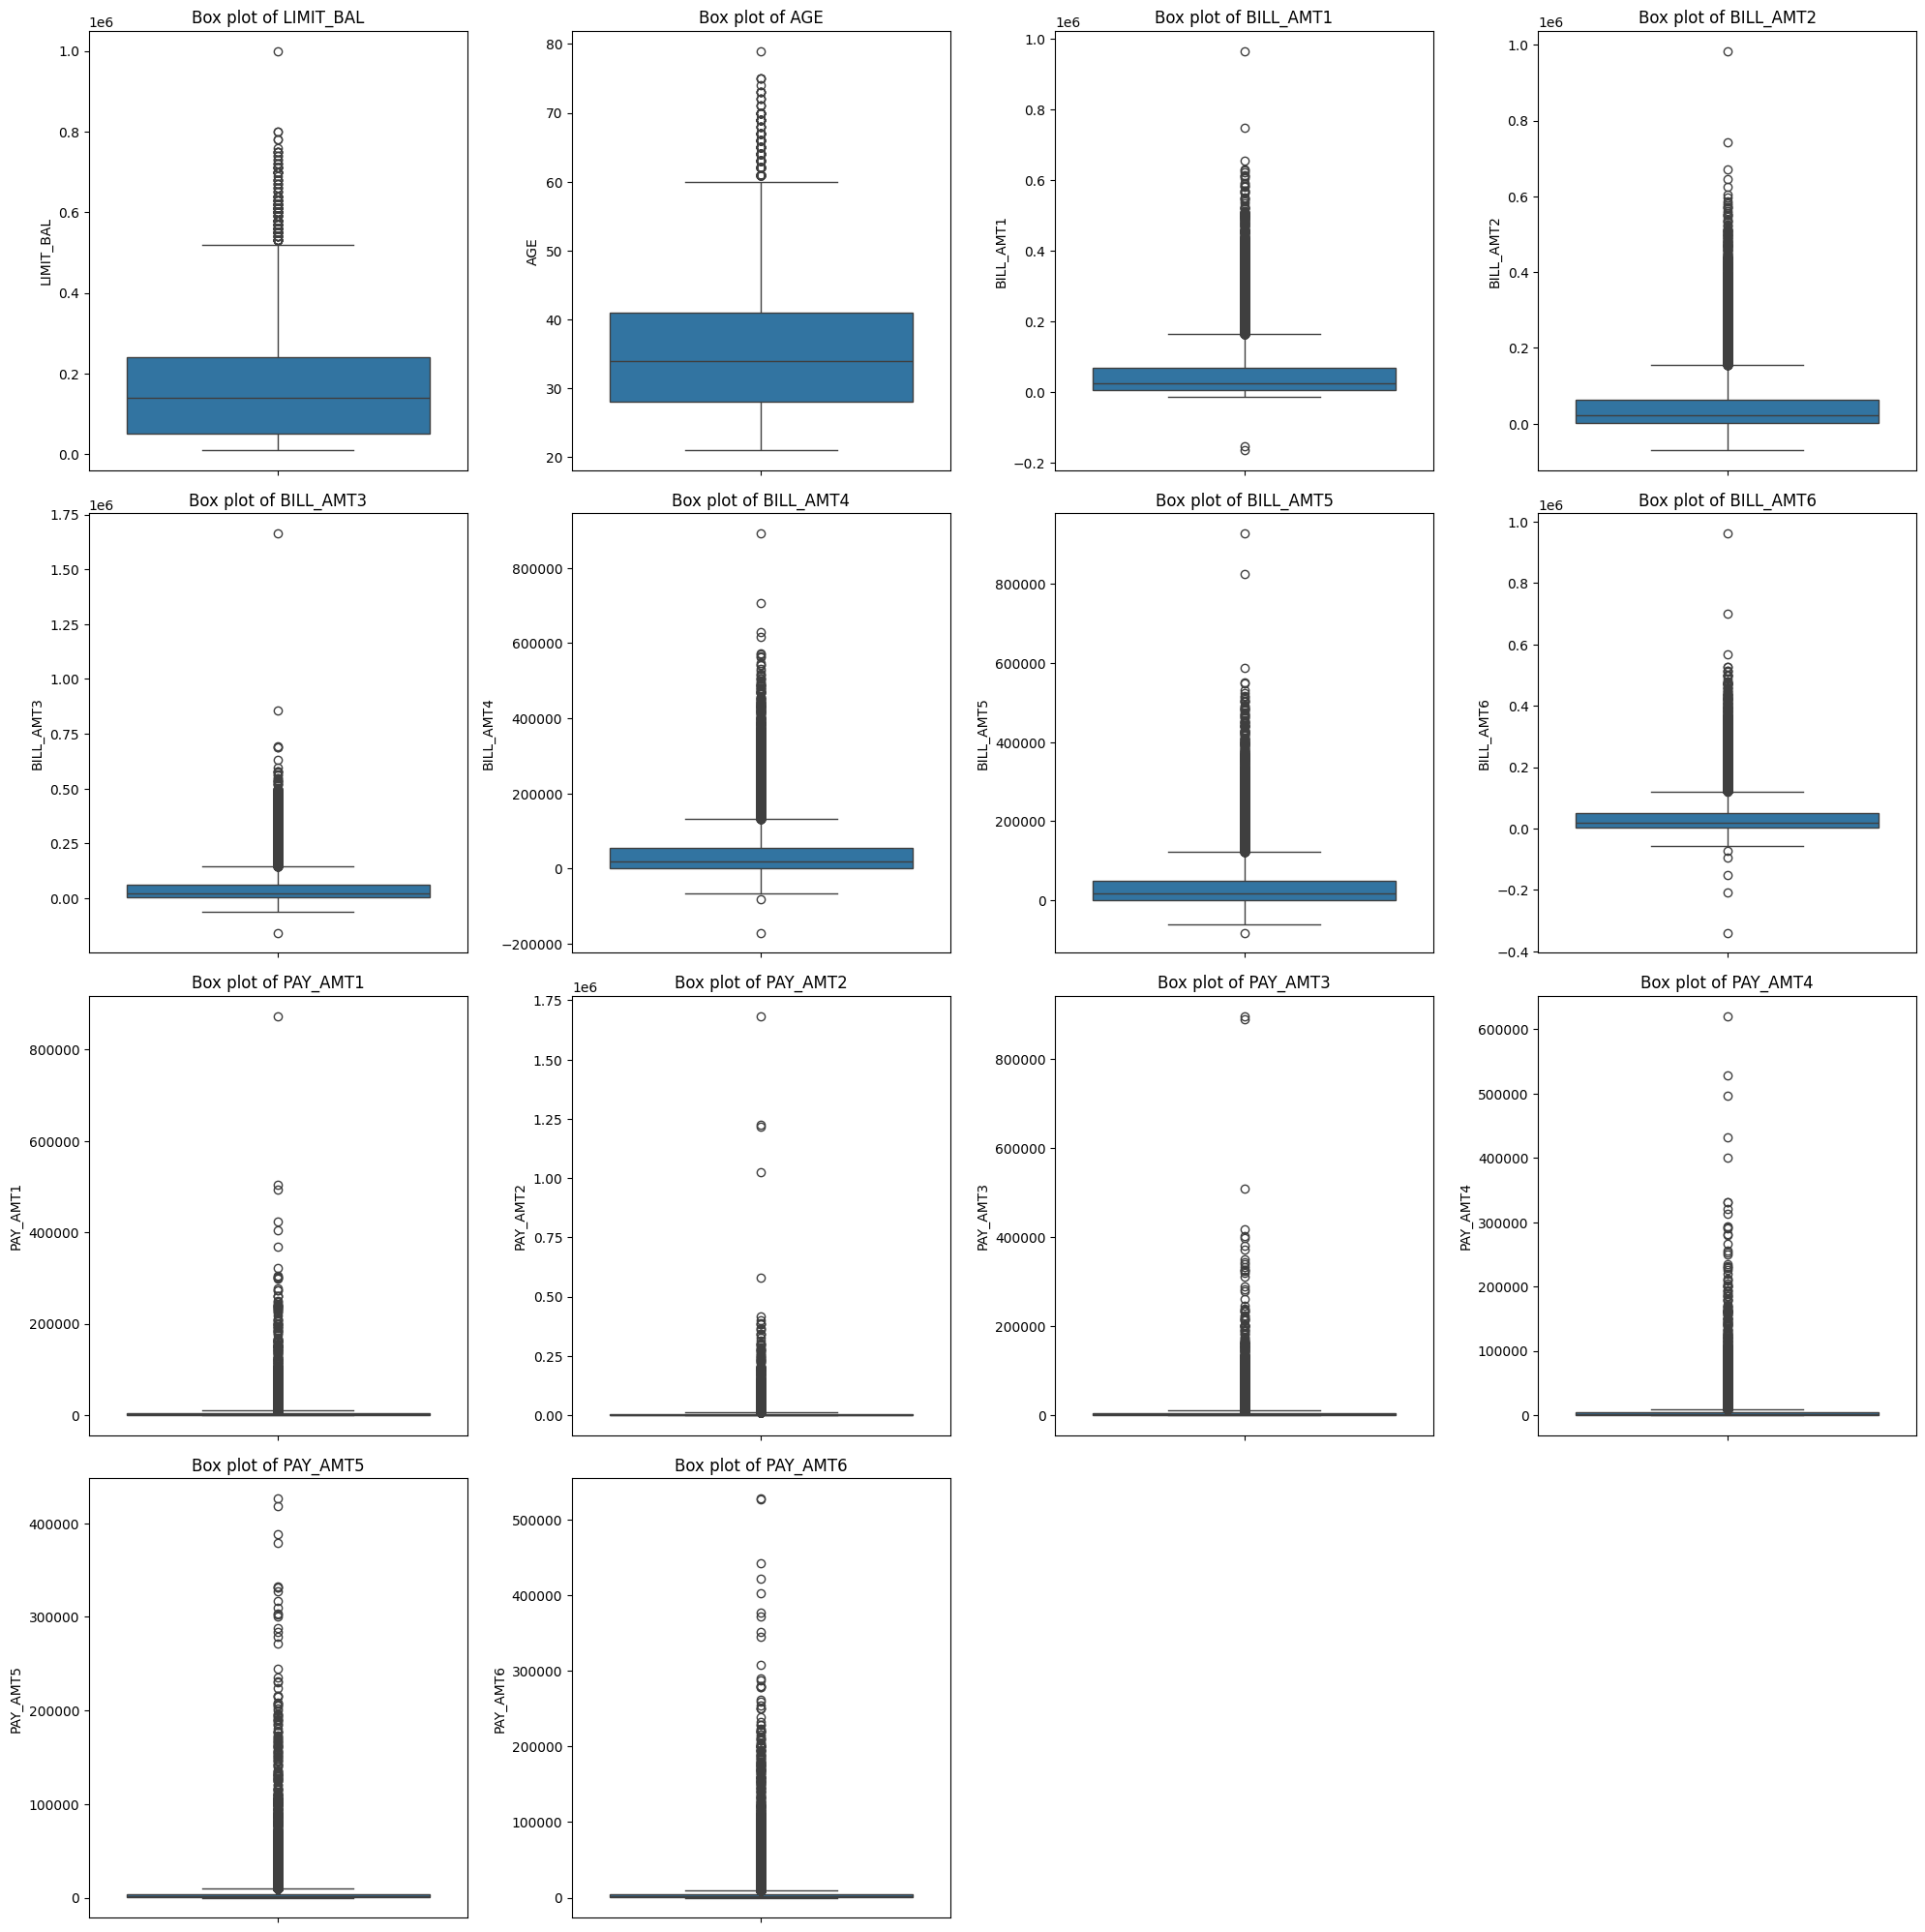

In [ ]:
# Boxplot for handling outlier

plt.figure(figsize=(20, 25))

for i, column in enumerate(num_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y = df_credit[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Inferences from describe() and univariate analysis:
# Most numerical features are right skewed and contain extreme values.
# These extreme values represent genuine customer financial behavior rather than data entry errors.
# Therefore, outlier removal is not performed to preserve important information and avoid losing valid observations.

# Bivariate Analysis

## Plotting

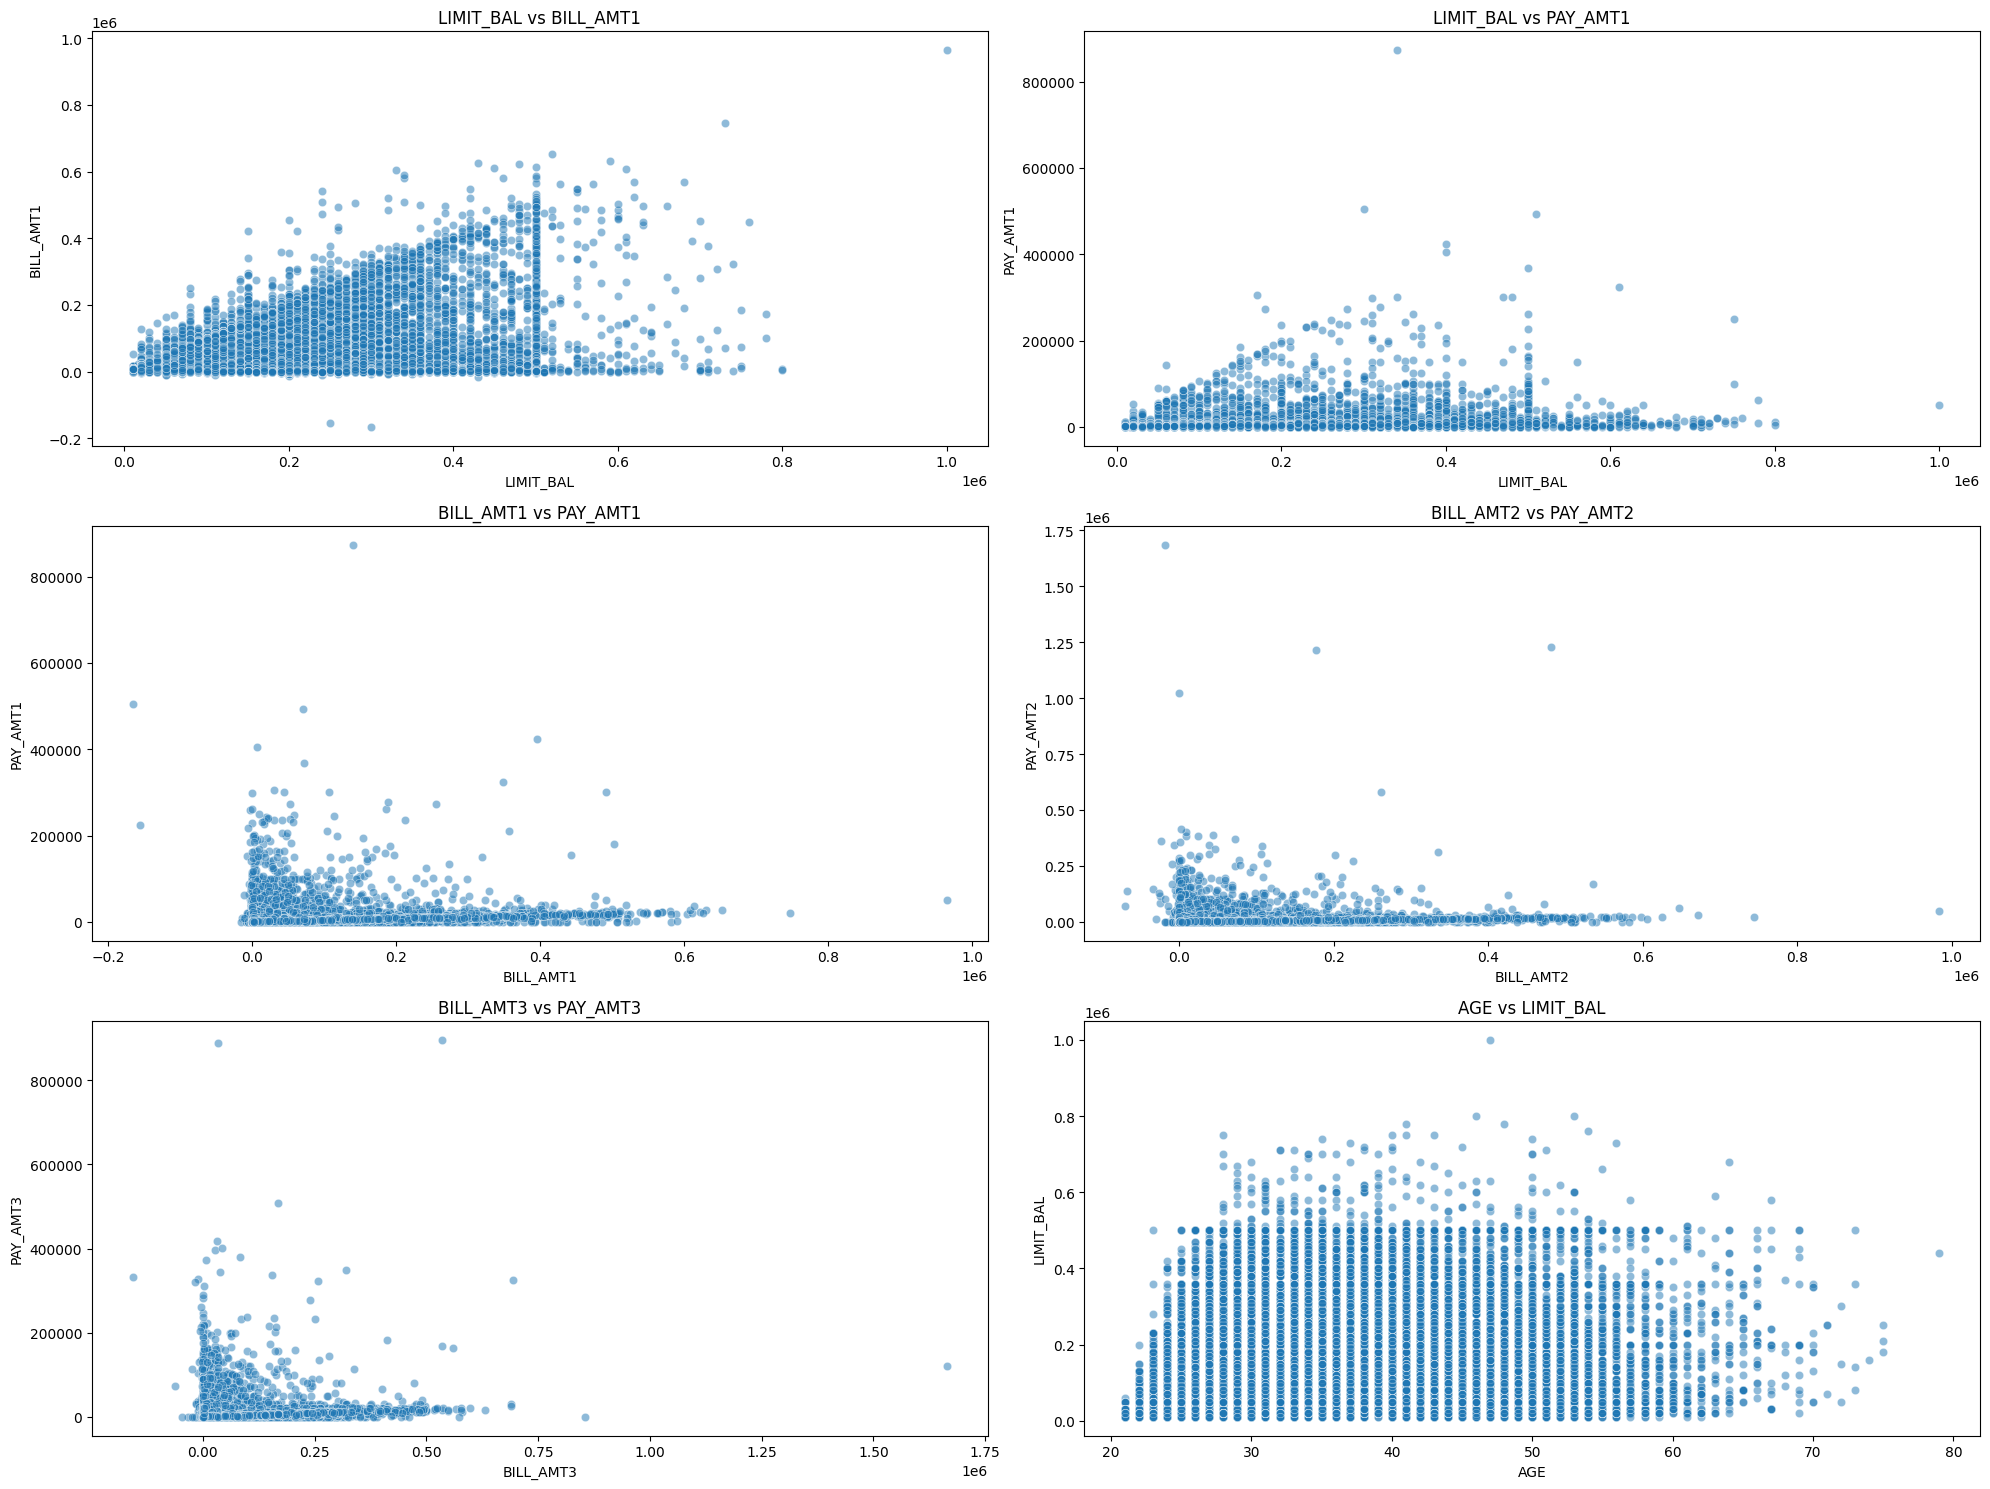

In [ ]:
# Scatter plots for Bivariate Analysis

feature_pairs = [
    ('LIMIT_BAL', 'BILL_AMT1'),
    ('LIMIT_BAL', 'PAY_AMT1'),
    ('BILL_AMT1', 'PAY_AMT1'),
    ('BILL_AMT2', 'PAY_AMT2'),
    ('BILL_AMT3', 'PAY_AMT3'),
    ('AGE', 'LIMIT_BAL')
]

plt.figure(figsize=(20, 15))

for i, (x, y) in enumerate(feature_pairs):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x = df_credit[x], y = df_credit[y], alpha = 0.5)
    plt.title(f'{x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)

plt.tight_layout()
plt.show()

## Correlation

In [ ]:
# Finding Pearson's correlation coefficient to measure linear relationship b/w continuous numerical columns

# Matrix 1: to find any mutli-collinearity b/w the 14 numerical features
corr_mat_num = df_credit[num_cols].corr()
corr_mat_num

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.144713,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
AGE,0.144713,1.000000,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
BILL_AMT1,0.285430,0.056239,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341
BILL_AMT2,0.278314,0.054283,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256
BILL_AMT3,0.283236,0.053710,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326
BILL_AMT4,0.293988,0.051353,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941,0.233012,0.207564,0.300023,0.130191,0.160433,0.177637
BILL_AMT5,0.295562,0.049345,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197,0.217031,0.181246,0.252305,0.293118,0.141574,0.164184
BILL_AMT6,0.290389,0.047613,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000,0.199965,0.172663,0.233770,0.250237,0.307729,0.115494
PAY_AMT1,0.195236,0.026147,0.140277,0.280365,0.244335,0.233012,0.217031,0.199965,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735
PAY_AMT2,0.178408,0.021785,0.099355,0.100851,0.316936,0.207564,0.181246,0.172663,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634


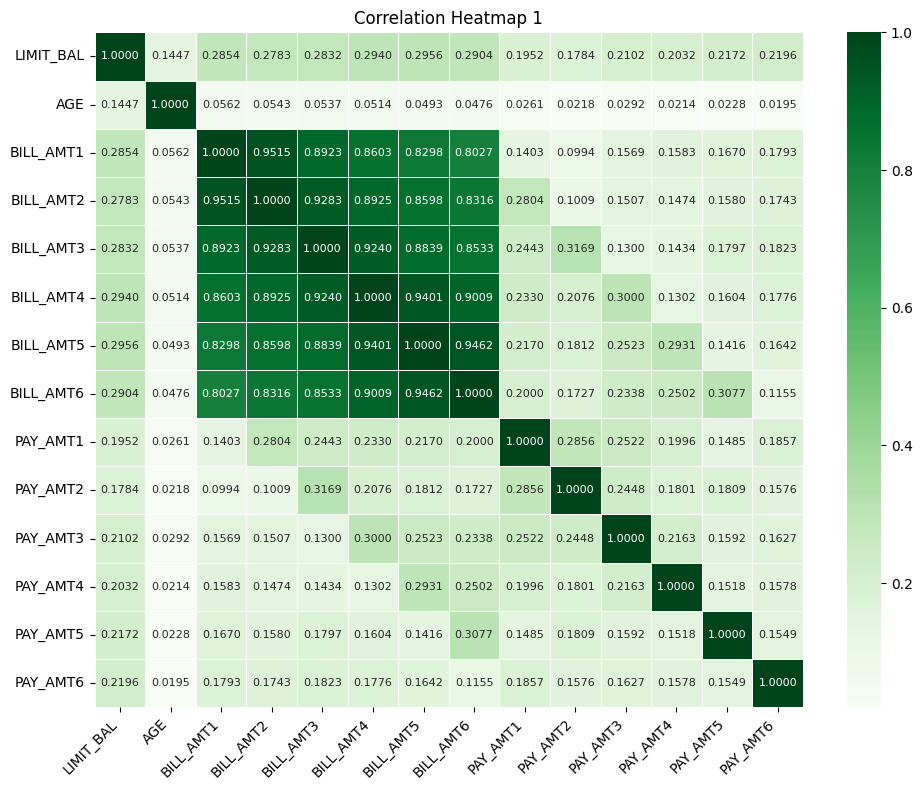

In [ ]:
# Correlation Heatmap 1: of only numerical feature cols

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_mat_num,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title('Correlation Heatmap 1')

plt.tight_layout()
plt.show()

In [ ]:
# Inference:
    # The BILL_AMT variables exhibit high positive correlations, especially b/w adjacent months.
    # This is because they represent the same customer's financial behaviour across 6 consecutive months.
    # Correlation decreases as the time gap between months increases, reflecting changes in spending over time.
    # Since these features capture historical information rather than duplicate measurements, they were retained despite multicollinearity

In [ ]:
# Matrix 2: to check collinearity b/w the 14 numerical features and target feature
corr_mat_target = df_credit[num_cols + ['default payment next month']].corr()
corr_mat_target['default payment next month']

,default payment next month
LIMIT_BAL,-0.153520
AGE,0.013890
BILL_AMT1,-0.019644
BILL_AMT2,-0.014193
BILL_AMT3,-0.014076
BILL_AMT4,-0.010156
BILL_AMT5,-0.006760
BILL_AMT6,-0.005372
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579


In [ ]:
# Inference:
  # Correlation analysis showed that most continuous numerical features have weak linear relationships with the target variable.
  # Note: In target col -> higher value = 1 (default), lower value = 0 (no default)

  # LIMIT_BAL exhibited the strongest linear relationship (r = -0.154),
      # -ve indicates that customers with higher credit limits tend to have a lower probability of default (i.e., target col val is 0)

  # The PAY_AMT variables also showed weak negative correlations,
      # suggesting that larger repayment amounts are associated with a reduced likelihood of default

  # The BILL_AMT variables and AGE show negligible linear correlations with target.


# Since Pearson correlation captures only linear associations, these results will be complemented with Mutual Information analysis,
    # to identify features that may have more relevant non-linear relationships with the target.

# Train Test Split

In [ ]:
# Split into features and target
y = df_credit['default payment next month']                            # Target
X = df_credit.drop(columns= ['default payment next month'],axis=1)     # Feature

# Split into test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

# Mutual Information

In [ ]:
# using classif MI, as the target col is binary and several features are continuous numerical
# discrete features can be identified by parameter 'discrete = ',
    # but it requires either a Boolean mask OR list/array of those column indices

# creating Boolean mask, this creates an Boolean array of columns in X, indicating presence/absence of cat_cols in it using True/False
discrete_mask = X.columns.isin(cat_cols)
discrete_mask


array([False,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [ ]:
# Mutual Information Classifier - to detect non-linear relationships b/w features and target
mi = mutual_info_classif(X, y, discrete_features = discrete_mask, random_state = 42)
mi

array([0.01519361, 0.00079304, 0.00296187, 0.00046822, 0.00314013,
       0.07605263, 0.04905609, 0.0372781 , 0.0328878 , 0.0305436 ,
       0.02642224, 0.01116204, 0.00631931, 0.00642298, 0.00262078,
       0.0076454 , 0.00547025, 0.02330462, 0.01628362, 0.01694217,
       0.01581689, 0.01279914, 0.01052787])

In [ ]:
# Converting mi array to Series with index as the column names of X
mi_scores = pd.Series(mi, index = X.columns, name = "Mutual Information")
mi_scores = mi_scores.sort_values(ascending = False)
mi_scores

,Mutual Information
PAY_0,0.076053
PAY_2,0.049056
PAY_3,0.037278
PAY_4,0.032888
PAY_5,0.030544
PAY_6,0.026422
PAY_AMT1,0.023305
PAY_AMT3,0.016942
PAY_AMT2,0.016284
PAY_AMT4,0.015817


In [ ]:
# Inference:
  # The repayment status variables (PAY_0–PAY_6) exhibited the highest predictive feature importance
  # demographic variables - AGE, EDUCATION, SEX and MARRIAGE showed relatively low mutual information

# However, these features were retained because:
    # they represent meaningful customer characteristics
    # did not show any multicollinearity
    # they may contribute to the target through interactions with other variables
    # Dropping 2 cols out of 23 doesn't help much to increase dimensionality or reduce computational load

# If absolutely required, cols SEX and MARRIAGE can be dropped as they show almost 0 MI.

# Scaling

In [ ]:
# Scale only numerical columns
# Using the Standard Scaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Display information

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

print("\n Scaled Training Data:")
X_train[num_cols].head(5)

X_train shape : (24000, 23)
X_test shape  : (6000, 23)
y_train shape : (24000,)
y_test shape  : (6000,)

 Scaled Training Data:


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
25295,-0.828895,-1.250441,-0.004202,0.006732,-0.036620,0.033014,-0.075477,-0.039622,-0.209915,-0.192114,-0.185534,-0.228651,-0.227628,-0.213373
23909,-0.674490,-1.032737,-0.687458,-0.685394,-0.681772,-0.665343,-0.658155,-0.651270,-0.332545,-0.280512,-0.259717,-0.299868,-0.307772,-0.289612
25048,-0.520084,2.015129,-0.190918,-0.043160,0.183752,0.459310,0.507414,0.513624,0.251410,0.437390,0.534571,-0.299868,-0.307772,-0.289612
17022,-0.674490,-1.359294,-0.601822,-0.571323,-0.533953,-0.490353,-0.488512,0.184838,-0.215754,-0.184792,-0.176617,-0.237342,2.248771,-0.179184
5917,0.251945,1.144310,-0.677795,-0.611491,-0.647726,-0.672821,-0.663358,-0.653809,-0.006114,-0.160862,-0.286031,-0.299868,-0.307772,-0.289612


# Feature Encoding

In [ ]:
# Check for categorical (object) columns

cat_cols = df_credit.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)
if len(cat_cols) == 0:
    print("No encoding required. All categorical features are already numerically encoded.")

Categorical Columns: Index([], dtype='object')
No encoding required. All categorical features are already numerically encoded.


## Categorical Feature Encoding

The dataset contains categorical features such as `SEX`, `EDUCATION`, `MARRIAGE`, and `PAY_0` to `PAY_6`. These features are already represented using numerical codes in the original dataset.

Therefore, no additional encoding (Label Encoding or One-Hot Encoding) was performed during preprocessing. The encoded values can be directly used by machine learning algorithms.

# Feature Engineering Decisions

### Dropped the ID Column

Decision: Removed the ID column from the dataset.

Reason: The ID is a unique identifier for each customer and does not contain predictive information related to credit default.





### Identified the Target Variable

Target Column: default payment next month

Reason: This column indicates whether a customer defaulted on their payment in the following month.

* 0 = No Default
* 1 = Default

### Categorical Features

* SEX
* EDUCATION
* MARRIAGE
* PAY_0
* PAY_2
* PAY_3
* PAY_4
* PAY_5
* PAY_6

Reason:
These variables represent categories rather than continuous measurements. Although stored as integers, their values are labels or ordered categories.

### Numerical Features

* LIMIT_BAL
* AGE
* BILL_AMT1–BILL_AMT6
* PAY_AMT1–PAY_AMT6

Reason:
These columns contain continuous numerical values on which arithmetic operations such as mean, variance, and standard deviation are meaningful.

### Applied Feature Scaling

Method: StandardScaler

Applied To: Only numerical features.

Reason: Numerical features have different ranges and contain outliers.

It transforms each feature to:
* Mean = 0
* Standard Deviation = 1

It preserves the distribution of the data.

Scaling was performed after train-test splitting, preventing data leakage.

### Did Not Scale Categorical Features

Reason: Categorical variables represent classes rather than measurable quantities.

We do not use  MinMaxScaler  because the dataset contains large variations and outliers. Since MinMaxScaler is sensitive to outliers, it can compress most data into a small range.

## Train-Test Split Before Scaling

Decision: Split the dataset into training (80%) and testing (20%) sets before scaling.

Reason: The scaler was fitted only on the training data and used to transform both the training and testing data.


# Feature Selection

All remaining features (except ID) were retained because all remaining features are relevant to predicting credit default.

* LIMIT_BAL - Reflects the customer's available credit.
* AGE - Provides demographic information.
* PAY_0–PAY_6 - Describe repayment history.
* BILL_AMT1–BILL_AMT6 - Indicate monthly bill amounts.
* PAY_AMT1–PAY_AMT6 - Represent monthly repayment amounts.

# Verify final dataset

In [ ]:
# Check the shape of the datasets
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

# Check for missing values
print("\nMissing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

# Verify data types
print("\nData Types:")
print(X_train.dtypes)

# Display first five rows of the processed training data
print("\nProcessed Training Data:")
print(X_train.head(5))

Training Features Shape : (24000, 23)
Testing Features Shape  : (6000, 23)
Training Target Shape   : (24000,)
Testing Target Shape    : (6000,)

Missing values in X_train:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

Missing values in X_test:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

Data Types:
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE 

# Save the final preprocessed dataset


In [ ]:
# # Save training dataset
# train_data = X_train.copy()
# train_data['default payment next month'] = y_train
# train_data.to_csv('credit_default_train.csv', index=False)

# # Save testing dataset
# test_data = X_test.copy()
# test_data['default payment next month'] = y_test
# test_data.to_csv('credit_default_test.csv', index=False)

# print("Training and testing datasets saved successfully!")

In [ ]:
# # Downloading the train and test file
# from google.colab import files
# files.download('credit_default_train.csv')
# files.download('credit_default_test.csv')

### Summary of Preprocessing Steps

1. Loaded the dataset into a Excel file.
2. Inspected the dataset using head(), info(), describe(), missing values and duplicates.
3. Removed the 'ID' column as it is a unique identifier and does not contribute to prediction.
4. Identified 'default payment next month' as the target variable and separated the feature and target columns.
5. Classified the features into categorical ('SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0'–'PAY_6') and numerical ('LIMIT_BAL', 'AGE', 'BILL_AMT1'–'BILL_AMT6', 'PAY_AMT1'–'PAY_AMT6') columns.
6. Split the dataset into 80% training and 20% testing sets using 'train_test_split()'.
7. Conducted correlation analysis.
8. Calculated Mutual Information scores for feature importance.
9. Applied StandardScaler to scale only the numerical features, while keeping the categorical features unchanged.
10. Verified the processed dataset by checking its shape, data types, missing values, and sample records.
11. Saved the final preprocessed training and testing datasets for model development.

# Model Building

## Logistic Regression

### Baseline Logistic Regression

In [ ]:
# creating object
log_reg = LogisticRegression()

# train the model
log_reg.fit(X_train, y_train)

# make predictions on X_test
y_pred_log_reg = log_reg.predict(X_test)

In [ ]:
# evaluate the model by comparing with y_test
print("Evaluating Baseline Logistic Regression Model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_log_reg))
print("Precision :", precision_score(y_test, y_pred_log_reg))
print("Recall :", recall_score(y_test, y_pred_log_reg))
print("F1 Score :", f1_score(y_test, y_pred_log_reg))

clsf_log_reg = classification_report(y_test,y_pred_log_reg)
print("\nClassification Report :")
print(clsf_log_reg)

conf_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix :")
print(conf_log_reg)

Evaluating Baseline Logistic Regression Model:

Accuracy : 0.8153333333333334
Precision : 0.6787330316742082
Recall : 0.23696682464454977
F1 Score : 0.351288056206089

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      4734
           1       0.68      0.24      0.35      1266

    accuracy                           0.82      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.80      0.82      0.78      6000


Confusion Matrix :
[[4592  142]
 [ 966  300]]


In [ ]:
# Inference (Evaluation Metrics):
# Logistic Regression has accuracy of 81.53%, indicating good overall classification performance.
# The model correctly identified most 'non-default' customers (Class 0), with a high precision (0.83) and recall (0.97).

# The 'default' class (Class 1) had a precision of 0.68, meaning 68% of predicted defaulters were actually defaulters.
# However, 'default' class  has low Recall = 0.24, indicating that many actual defaulters were misclassified as non-defaulters

# The confusion matrix confirms that the model produces a high number of false negatives (966), which is undesirable
# Overall, the model serves as a good baseline, but more advanced classification models may improve the detection of defaulting customers.

In [ ]:
# Thus key evaluation metric is Recall i.e., penalizing False Negatives
      # Default Customers who where falsely classified as Non-Default

### Cross-Validation

#### K-Fold Cross Validation

In [ ]:
# Since this is a classification problem with an imbalanced target (around 78% non-default and 22% default),
    # StratifiedKFold ensures that every fold maintains approximately the same class distribution.

cv_kfold = StratifiedKFold(
    n_splits=5,      # Split the training data into 5 folds   =>  k=5
    shuffle=True,    # Shuffle the data before splitting
    random_state=45  # Ensures reproducibility
)

In [ ]:
# Create the baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

In [ ]:
# Perform 5-Fold Cross Validation on the TRAINING DATA ONLY

# important than simply achieving high accuracy.

cv_kfold_scores = cross_val_score(
    estimator=log_reg,
    X=X_train,
    y=y_train,
    cv=cv_kfold,
    scoring='recall'    # scoring='recall' because correctly detecting actual default customers is more important than simple accuracy
)


**Recall** was chosen because:

* The main objective is to identify as many defaulting customers as possible.
* In credit default prediction, missing a true defaulter (False Negative) is generally more costly than incorrectly classifying a non-defaulter as a defaulter (False Positive).
* Although F1-score provides a balance between Precision and Recall, Recall was prioritized since minimizing missed defaulters was the primary objective of this project.

In [ ]:
print("5 k-Fold Cross Validation Recall Scores:")
print(cv_kfold_scores)

print("\nMean Recall:", cv_kfold_scores.mean())
print("Standard Deviation:", cv_kfold_scores.std())

5 k-Fold Cross Validation Recall Scores:
[0.27374302 0.23649907 0.25698324 0.22905028 0.24301676]

Mean Recall: 0.24785847299813782
Standard Deviation: 0.015871341342765372


In [ ]:
# Inference:
  # • The model was evaluated using 5-Fold Stratified Cross Validation.
  # • The mean recall represents the average performance across all folds.
  # • A small standard deviation indicates consistent model performance.
  # • Cross Validation provides a more reliable estimate than a single train-test split.

#### Hyperparameter Tuning using GridSearchCV

In [ ]:
# Define the hyperparameters to be tested
# -------------------------------------------------------------
# C              -> Regularization strength
# solver         -> Optimization algorithm
# penalty        -> Regularization type
# class_weight   -> Gives higher importance to the minority class

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

In [ ]:
# Build the Grid Search model
# -------------------------------------------------------------
# GridSearchCV tests every possible combination of the above
# hyperparameters using 5-Fold Cross Validation.

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='recall',           # Optimizing for Recall
    n_jobs=-1
)

In [ ]:
# Train the Grid Search model on the training data
grid.fit(X_train, y_train)


# Display the best hyperparameters found

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Recall:")
print(grid.best_score_)

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross Validation Recall:
0.6415270018621972


In [ ]:
# Inference:
  # GridSearchCV identified the optimal hyperparameters using 5-Fold Cross Validation.
    # The best model used C = 10, L2 regularization, liblinear solver, and balanced class weights.
    # Assigning balanced class weights improved the model's ability to identify the minority default class.
  # The best cross-validation recall increased to 0.642,
    # indicating a substantial improvement in detecting default cases during validation compared to the baseline model.

In [ ]:
# Retrieve the best model identified by GridSearchCV

best_model_grid = grid.best_estimator_

In [ ]:
# Predict on the unseen test data
y_pred_grid = best_model_grid.predict(X_test)

In [ ]:
# Evaluating GridSearchCV optimized model

print("Evaluating GridSearchCV optimized model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_grid))
print("Precision :", precision_score(y_test, y_pred_grid))
print("Recall :", recall_score(y_test, y_pred_grid))
print("F1 Score :", f1_score(y_test, y_pred_grid))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_grid))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_grid))

Evaluating GridSearchCV optimized model:

Accuracy : 0.6921666666666667
Precision : 0.3686114880144731
Recall : 0.6437598736176935
F1 Score : 0.46879493816508483

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4734
           1       0.37      0.64      0.47      1266

    accuracy                           0.69      6000
   macro avg       0.62      0.67      0.63      6000
weighted avg       0.77      0.69      0.72      6000


Confusion Matrix:

[[3338 1396]
 [ 451  815]]


In [ ]:
# Inference:
    # Hyperparameter tuning increased the recall from 0.24 to 0.64, allowing the model to identify substantially more defaulting customers.
    # The F1-score also improved from 0.35 to 0.47, indicating a better balance between precision and recall.
    # Accuracy and precision decreased because the optimized model classified more customers as defaulters,
      # increasing the number of false positives.
    # The optimized model is therefore more suitable when the priority is to minimize false negatives
      # and identify as many potential defaulters as possible.

| Metric    | Baseline LR | GridSearchCV LR |
| --------- | ----------: | --------------: |
| Accuracy  |  **81.53%** |          69.22% |
| Precision |    **0.68** |            0.37 |
| Recall    |        0.24 |        **0.64** |
| F1-score  |        0.35 |        **0.47** |


#### Randomised search CV

In [ ]:
# Define the Hyperparameter Search Space
# ==========================================================
# These are the same hyperparameters used in GridSearchCV.
# RandomizedSearchCV will randomly select combinations instead of trying every possible combination.

param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

In [ ]:
# Create the Randomized Search Model
# ==========================================================
# n_iter = Number of random parameter combinations to test.
# Since there are only 20 possible combinations in total,
# we choose n_iter=10 to evaluate about half of them.

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=45),

    param_distributions=param_dist,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=45,
    n_jobs=-1
)

In [ ]:
# Train the Randomized Search Model
random_search.fit(X_train, y_train)


# Display the Best Hyperparameters

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Recall:")
print(random_search.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 10}

Best Cross Validation Recall:
0.6415270018621972


In [ ]:
# Retrieve the best model found by RandomizedSearchCV
best_model_random = random_search.best_estimator_

# Predict on the unseen test data
y_pred_random = best_model_random.predict(X_test)

In [ ]:
# Evaluate the RandomizedSearchCV Model

print("Evaluating RandomizedSearchCV Optimized Model\n")

print("Accuracy :", accuracy_score(y_test, y_pred_random))
print("Precision :", precision_score(y_test, y_pred_random))
print("Recall :", recall_score(y_test, y_pred_random))
print("F1 Score :", f1_score(y_test, y_pred_random))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_random))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_random))

Evaluating RandomizedSearchCV Optimized Model

Accuracy : 0.6921666666666667
Precision : 0.3686114880144731
Recall : 0.6437598736176935
F1 Score : 0.46879493816508483

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4734
           1       0.37      0.64      0.47      1266

    accuracy                           0.69      6000
   macro avg       0.62      0.67      0.63      6000
weighted avg       0.77      0.69      0.72      6000


Confusion Matrix:

[[3338 1396]
 [ 451  815]]


### Comparision  

| Metric    | Baseline LR |k-Fold CV LR | GridSearchCV LR | RandomizedSearchCV LR |
| --------- | ----------: |-----------: |--------------: | ---------------------:|
| Accuracy  |  **81.53%** |                                 - |          69.22% |                69.21% |
| Precision |  **67.87%** |                                 - |         36.86% |                36.86% |
| Recall    |      23.69% |                         **24.78%**|      **64.37%** |                64.37% |
| F1-score  |      35.12% |                                 - |       **46.87%** |                46.87% |

* The baseline Logistic Regression model achieved the highest accuracy (81.53%) and precision (0.68), but its recall (0.24) was low, indicating that many actual defaulters were missed.

* Stratified 5-Fold Cross Validation produced a mean recall of 0.248, demonstrating consistent performance of the baseline model across different training subsets.

* Hyperparameter tuning using GridSearchCV significantly improved the recall to 0.644, enabling the model to identify a much larger proportion of defaulting customers   
The improvement in recall was accompanied by a decrease in accuracy and precision due to an increase in false positive predictions. This trade-off is expected when optimizing specifically for recall.

* RandomizedSearchCV produced the same optimal hyperparameters and evaluation metrics as GridSearchCV. Since the search space was relatively small (10), RandomizedSearchCV was able to identify the same optimal solution while evaluating fewer hyperparameter combinations, much faster

### Conclusion

Since the primary objective of credit default prediction is to minimize false negatives and detect as many potential defaulters as possible,   
The **GridSearchCV-optimized for Recall** was selected as the final Logistic Regression Model  
So the best paramters found after GridSearchCV will be applied hereafter

### Ensemble Modelling - BaggingClassifier

Reason for choosing BaggingClassifier:

* Bagging was selected because it allows the optimized Logistic Regression model to be used as the base estimator.
* Most Boosting techniques (AdaBoost, Gradient Boosting and XGBoost), which are primarily designed to sequentially improve weak learners such as decision trees
* BaggingClassifier was used because this is a binary classification problem. It combines the predictions of multiple Logistic Regression classifiers using majority voting.

In [ ]:
# Create the optimized Logistic Regression model using the hyperparameters obtained from GridSearchCV
# This is then taken as the base estimator for Bagging.

best_log_reg = LogisticRegression(
    C=10,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=45
)

In [ ]:
# model object

bagging_log_reg = BaggingClassifier(
    estimator=best_log_reg,     # base model taken for bagging
    n_estimators=10,
    max_samples=0.8,            # more sample count, as there's ~24k training data
    bootstrap=True,             # Sampling with replacement => Samples can repeat i.e., bootstrap datasets overlap.
    random_state=45
)

In [ ]:
# Train the Bagging Classifier
bagging_log_reg.fit(X_train, y_train)

# Make predictions on X_test
y_pred_bag_lr = bagging_log_reg.predict(X_test)

In [ ]:
# Evaluating Bagging model's performance

print("Evaluating Bagging Classifier\n")

print("Accuracy :", accuracy_score(y_test, y_pred_bag_lr))
print("Precision :", precision_score(y_test, y_pred_bag_lr))
print("Recall :", recall_score(y_test, y_pred_bag_lr))
print("F1 Score :", f1_score(y_test, y_pred_bag_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bag_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_bag_lr))

Evaluating Bagging Classifier

Accuracy : 0.6953333333333334
Precision : 0.37227272727272726
Recall : 0.6469194312796208
F1 Score : 0.4725908828620889

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.71      0.79      4734
           1       0.37      0.65      0.47      1266

    accuracy                           0.70      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.70      0.72      6000


Confusion Matrix:

[[3353 1381]
 [ 447  819]]


### Final Model Comparison

| Metric | Baseline Logistic Regression | Stratified 5-Fold CV LR| GridSearchCV Optimized LR | RandomizedSearchCV Optimized LR | Bagging + Optimized LR |
|:-------|-----------------------------:|------------------------:|--------------------------:|--------------------------------:|-----------------------:|
| **Accuracy** | **81.53%** | – | 69.21% | 69.21% | **69.53%** |
| **Precision** | **67.87%** | – | 36.86% | 36.86% | **37.27%** |
| **Recall** | 23.69% | **24.78%** | **64.37%** | 64.37% | **64.69%** |
| **F1-Score** | 35.12% | – | **46.87%** | 46.87% | **47.25%** |

In [ ]:
comparison = pd.DataFrame({             # dict to df
    "Model": [
        "Baseline Logistic Regression",
        "Stratified 5-Fold Cross Validation",
        "GridSearchCV Optimized Logistic Regression",
        "RandomizedSearchCV Optimized Logistic Regression",
        "Bagging + Optimized Logistic Regression"
    ],
    "Accuracy": [0.8153, "-", 0.6921, 0.6921, 0.6953],
    "Precision": [0.6787, "-", 0.3686, 0.3686, 0.3727],
    "Recall": [0.2369, 0.2478, 0.6437, 0.6437, 0.6469],   # Mean Cross Validation Recall used for k-fold cv
    "F1-Score": [ 0.3512, "-", 0.4687, 0.4687, 0.4725]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Logistic Regression,0.8153,0.6787,0.2369,0.3512
1,Stratified 5-Fold Cross Validation,-,-,0.2478,-
2,GridSearchCV Optimized Logistic Regression,0.6921,0.3686,0.6437,0.4687
3,RandomizedSearchCV Optimized Logistic Regression,0.6921,0.3686,0.6437,0.4687
4,Bagging + Optimized Logistic Regression,0.6953,0.3727,0.6469,0.4725


#### Final Comparision Study
  
* **Baseline Logistic Regression model** -  achieved the highest accuracy (81.53%) and precision (67.87%), but its recall (23.69%) was low, indicating that many defaulting customers were not identified.

* **Stratified 5-Fold Cross Validation** - produced a mean recall of 24.79%, showing that the baseline model performed consistently across different training subsets.

* **Hyperparameter tuning using GridSearchCV** - significantly improved recall to 64.38%, resulting in a much better ability to identify defaulting customers. This improvement came with a decrease in accuracy and precision due to an increase in false positive predictions.

* **RandomizedSearchCV** - produced the same optimal hyperparameters and evaluation metrics as GridSearchCV. Since the hyperparameter search space was relatively small, RandomizedSearchCV successfully identified the same optimal solution while evaluating fewer parameter combinations.

* **Bagging** - by using the optimized Logistic Regression as the base estimator, it produced a slight improvement over the tuned Logistic Regression model, increasing Accuracy (69.22% → 69.53%), Precision (36.86% → 37.23%), Recall (64.38% → 64.69%) and F1-score (46.88% → 47.26%).   
The improvement was small because Logistic Regression is already generally a stable, low-variance high-bias model, and Bagging generally provides greater benefits for high-variance models such as Decision Trees.

### Final Conclusion

This study developed a Logistic Regression model to predict credit card default payment using the UCI Credit Default dataset.

The baseline Logistic Regression model achieved good overall accuracy but showed poor performance in identifying defaulting customers, as reflected by its low recall.

To obtain a more reliable estimate of model performance, Stratified 5-Fold Cross Validation was performed. Hyperparameter tuning was then carried out using both GridSearchCV and RandomizedSearchCV. Both methods identified the same optimal hyperparameter combination, significantly improving recall from 23.69% to 64.38%, thereby enabling the model to identify a much larger proportion of defaulting customers.

Finally, Bagging was applied using the Recall-optimized Logistic Regression as the base estimator. The ensemble model produced a slight improvement in Accuracy, Precision, Recall and F1-score compared to the tuned Logistic Regression model.

Overall, the Bagging Classifier built on the optimized Logistic Regression was selected as the final model, as it achieved the best overall balance of evaluation metrics while maintaining the highest recall for identifying potential defaulting customers.

## Deep Learning - ANN  

### Compute Class weights

In [ ]:
# Compute class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.644122383252818), np.int64(1): np.float64(2.2346368715083798)}


### Create ANN Model

In [ ]:
# Building ANN model
# Model Object
ann_model = Sequential()

# Adding Input Layer + Hidden Layer 1
ann_model.add(Dense(
    units=64,
    activation='relu',
    kernel_regularizer=l2(0.001),
    input_shape=(X_train.shape[1],)
))

ann_model.add(BatchNormalization())   # Adding Batch Normalization
ann_model.add(Dropout(0.30))          # Dropout layer of 30% to reduce overfitting

# Adding Hidden Layer 2
ann_model.add(Dense(
    units=32,
    activation='relu',
    kernel_regularizer=l2(0.001)
))

ann_model.add(BatchNormalization())   # Adding Batch Normalization
ann_model.add(Dropout(0.20))          # Dropout layer of 20% to reduce overfitting

# Output Layer
ann_model.add(Dense(
    units=1,
    activation='sigmoid'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print: number of layers, neurons, trainable parameters

ann_model.summary()
print("\nNumber of Trainable Parameters:")
print(ann_model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)


Number of Trainable Parameters:
4033


### Compiling and adding Early Stopping

In [ ]:
# Defining optimizer
adam_optimizer = Adam(      # Adam (Adaptive Moment Estimation)
    learning_rate=0.001     # Added learning rate
)

# Compile the ANN
ann_model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',     # Loss Function: Binary Crossentropy
    metrics=['accuracy']            # Monitor training accuracy during learning
)

In [ ]:
# Early Stopping - Stops training when validation loss stops improving.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

### Model Training  

In [ ]:
# Train the ANN

history = ann_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    class_weight=class_weights, # added class weights
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6701 - loss: 0.7233 - val_accuracy: 0.7427 - val_loss: 0.6514
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7201 - loss: 0.6619 - val_accuracy: 0.7554 - val_loss: 0.6355
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7283 - loss: 0.6437 - val_accuracy: 0.7533 - val_loss: 0.6142
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7339 - loss: 0.6292 - val_accuracy: 0.7625 - val_loss: 0.5998
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7333 - loss: 0.6184 - val_accuracy: 0.7669 - val_loss: 0.5885
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7404 - loss: 0.6090 - val_accuracy: 0.7625 - val_loss: 0.5867
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7358 - loss: 0.6035 - val_accuracy: 0.7617 - val_loss: 0.5847
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7356 - loss: 0.5984 - val_accu

### Model Evaluation on Test Data

In [ ]:
# Evaluate on Test Data
loss_ann, accuracy_ann = ann_model.evaluate(X_test, y_test)

print("Test Loss :", loss_ann)
print("Test Accuracy :", accuracy_ann)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7850 - loss: 0.5442
Test Loss : 0.5441771745681763
Test Accuracy : 0.7850000262260437


### Prediction & Threshold Selection

In [ ]:
# Predict
y_pred_prob = ann_model.predict(X_test)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Evaluate multiple probability thresholds and select the one that provides the best trade-off between
    # Accuracy, Precision, Recall, and F1-score.

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

print(f"{'Threshold':<10}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1 Score':<12}")

results = []

for t in thresholds:
    y_pred_threshold = (y_pred_prob >= t).astype(int)     # Convert probabilities into class labels

    acc = accuracy_score(y_test, y_pred_threshold)        # Calculate evaluation metrics
    prec = precision_score(y_test, y_pred_threshold)
    rec = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append([t, acc, prec, rec, f1])               # Store results in results[]
    print(f"{t:<10.2f}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")          # Print results

Threshold Accuracy    Precision   Recall      F1 Score    
0.30      0.5150      0.2862      0.8689      0.4305      
0.35      0.6135      0.3284      0.7962      0.4651      
0.40      0.7062      0.3907      0.7014      0.5018      
0.45      0.7580      0.4473      0.6240      0.5211      
0.50      0.7850      0.4919      0.5790      0.5319      


In [ ]:
# Choosing best threshold
best_threshold = 0.40    # or 0.45 for better accuracy

y_pred_best = (y_pred_prob >= best_threshold).astype(int)

### Evaluation Metrics (after testing)

In [ ]:
# Model Evaluation

print("Evaluating ANN Model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_best))
print("Precision :", precision_score(y_test, y_pred_best))
print("Recall :", recall_score(y_test, y_pred_best))         # Primary evaluation metric
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best))

Evaluating ANN Model:

Accuracy : 0.7061666666666667
Precision : 0.3906731192256929
Recall : 0.7014218009478673
F1 Score : 0.5018366770274089

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      4734
           1       0.39      0.70      0.50      1266

    accuracy                           0.71      6000
   macro avg       0.64      0.70      0.65      6000
weighted avg       0.79      0.71      0.73      6000


Confusion Matrix:

[[3349 1385]
 [ 378  888]]


### Plotting

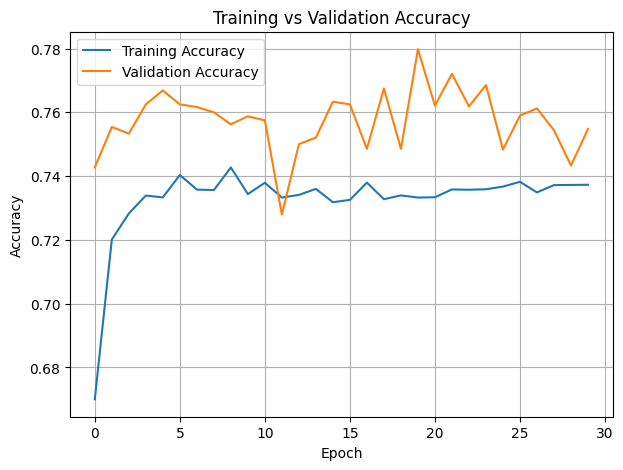

In [ ]:
# Plotting Accuracy

plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')          # Training Accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')    # Validation Accuracy
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

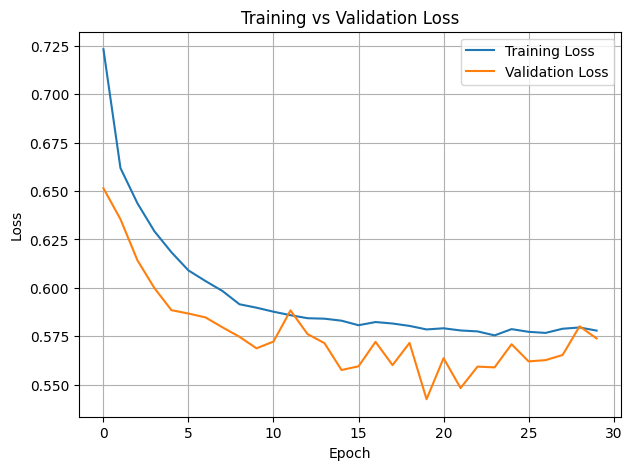

In [ ]:
# Plotting Loss

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')            # Training Loss
plt.plot(history.history['val_loss'], label='Validation Loss')      # Validation Loss
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()